# Section: Counterfactual Trade Balance
**Question:** If AI-related products had grown at the same rate as non-AI products
since 2023, what would the U.S. goods trade balance have been?

**Method:**
1. Compute monthly non-AI import/export growth index (2023 = 1.0 baseline).
2. Apply that index to the 2023-average AI level => counterfactual series.
3. Excess AI trade = actual minus counterfactual.
4. Counterfactual balance = actual balance + excess imports - excess exports.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import datetime as dt
import os


In [15]:
figfile = '../paper/figures/'
texfile = '../paper/tables/ai-trade-results.tex'
os.makedirs(figfile, exist_ok=True)
os.makedirs('paper/tables', exist_ok=True)


## Load Data


In [16]:
matlist = pd.read_csv('../data-input/hs10_classification_final_v3.csv')

matlist['relevance'] = matlist['relevance'].astype('category')

matlist['relevance'] = pd.Categorical(
    matlist['relevance'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
)

matlist['primary_category'] = matlist['primary_category'].astype('category')

matlist.rename(columns={'hs10_code': 'HS10'}, inplace=True)

In [17]:
df = pd.read_parquet('../data-input/TOTALdata-current.parquet')

df.rename(columns={'I_COMMODITY': 'HS10'}, inplace=True)

df["HS2"] = df["HS10"].str[0:2]
df["HS4"] = df["HS10"].str[0:4]

df["HS10"] = df["HS10"].astype('int64')

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["imports"] = df["CON_VAL_MO"].astype(float)

df["duty"] = df["CAL_DUT_MO"].astype(float)

df.rename({"I_COMMODITY_SDESC": "short_description"}, axis=1, inplace=True)

excluded_hs2 = ["27", "71", "98", "99"]
df = df[~df["HS2"].isin(excluded_hs2)]

# Merge relevance onto df
df = df.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"]], on='HS10', how='left')

print('Imports:', df.shape, '|', df['time'].min().strftime('%Y-%m'),
      'to', df['time'].max().strftime('%Y-%m'))

Imports: (2675340, 14) | 2013-01 to 2026-01


In [18]:
matlist_exp = pd.read_csv('../data-input/hs10_classification_imports_exports.csv')

matlist_exp['relevance'] = matlist_exp['relevance'].astype('category')

matlist_exp['relevance'] = pd.Categorical(
    matlist_exp['relevance'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
)

matlist_exp['primary_category'] = matlist_exp['primary_category'].astype('category')

matlist_exp.rename(columns={'hs10_code': 'HS10'}, inplace=True)

In [19]:
df_exp = pd.read_parquet('../data-input/TOTALexports-combined.parquet')

df_exp.rename(columns={'E_COMMODITY': 'HS10'}, inplace=True)

df_exp["HS2"] = df_exp["HS10"].str[0:2]
df_exp["HS4"] = df_exp["HS10"].str[0:4]

df_exp["HS10"] = df_exp["HS10"].astype('int64')

df_exp.time = pd.to_datetime(df_exp.time, format="%Y-%m")

df_exp["exports"] = df_exp["ALL_VAL_MO"].astype(float)

df_exp.rename({"E_COMMODITY_SDESC": "short_description"}, axis=1, inplace=True)

excluded_hs2 = ["27", "71", "98", "99"]
df_exp = df_exp[~df_exp["HS2"].isin(excluded_hs2)]

# Merge relevance onto df_exp
df_exp = df_exp.merge(matlist_exp[['HS10', 'relevance', 'primary_category', "reasoning"]], on='HS10', how='left')

print('Exports:', df_exp.shape, '|', df_exp['time'].min().strftime('%Y-%m'),
      'to', df_exp['time'].max().strftime('%Y-%m'))

Exports: (1387856, 12) | 2013-01 to 2026-01


## Build Monthly Series


In [20]:
# Monthly totals by relevance
imp_by_rel = (df.groupby(['relevance', 'time'], observed=True)['imports']
              .sum().reset_index())
exp_by_rel = (df_exp.groupby(['relevance', 'time'], observed=True)['exports']
              .sum().reset_index())

# Total monthly
imp_total = df.groupby('time', observed=True)['imports'].sum()
exp_total = df_exp.groupby('time', observed=True)['exports'].sum()

# Pivot wide
imp_wide = imp_by_rel.pivot(index='time', columns='relevance', values='imports').fillna(0)
exp_wide = exp_by_rel.pivot(index='time', columns='relevance', values='exports').fillna(0)
print('Import columns:', imp_wide.columns.tolist())
print('Export columns:', exp_wide.columns.tolist())

Import columns: ['Low', 'Medium', 'High']
Export columns: ['Low', 'Medium', 'High']


## Counterfactual Construction

**Question:** If AI-related products had grown at the same rate as non-AI products since 2023, what would the trade balance have been?

**Step 1: Non-AI growth index.**
Let $M_t^{\text{non}}$ denote non-AI (Low relevance) imports in month $t$, and $\bar{M}_{2023}^{\text{non}}$ the average monthly level in 2023. The non-AI growth index is:

$$g_t^{M} = \frac{M_t^{\text{non}}}{\bar{M}_{2023}^{\text{non}}}$$

with $g_t^{M} = 1$ on average in 2023 by construction. Define $g_t^{X}$ analogously for exports.

**Step 2: Counterfactual AI series.**
Let $M_t^{\text{AI}}$ be actual AI imports and $\bar{M}_{2023}^{\text{AI}}$ the 2023 average AI level. The counterfactual asks: what if AI imports had grown from the same 2023 base, but at the non-AI rate?

$$\widetilde{M}_t^{\text{AI}} = \bar{M}_{2023}^{\text{AI}} \cdot g_t^{M}, \qquad \widetilde{X}_t^{\text{AI}} = \bar{X}_{2023}^{\text{AI}} \cdot g_t^{X}$$

**Step 3: Excess AI trade.**
The AI boom contribution to each flow is the gap between actual and counterfactual:

$$E_t^{M} = M_t^{\text{AI}} - \widetilde{M}_t^{\text{AI}}, \qquad E_t^{X} = X_t^{\text{AI}} - \widetilde{X}_t^{\text{AI}}$$

**Step 4: Counterfactual trade balance.**
Let $B_t = X_t - M_t$ denote the actual goods trade balance (negative = deficit). The counterfactual balance replaces AI flows with their counterfactual levels, leaving non-AI flows unchanged:

$$\widetilde{B}_t = B_t + E_t^{M} - E_t^{X}$$

Intuitively, the AI boom widens the deficit when excess imports exceed excess exports ($E_t^M > E_t^X$). The term $E_t^M - E_t^X$ measures the net contribution of the AI boom to the trade deficit.

In [21]:
# Non-AI growth indices (2023 avg = 1.0)
nonai_imp = imp_wide['Low'].copy()
nonai_exp = exp_wide['Low'].copy()
nonai_imp_2023_avg = nonai_imp.loc['2023'].mean()
nonai_exp_2023_avg = nonai_exp.loc['2023'].mean()
nonai_imp_idx = nonai_imp / nonai_imp_2023_avg
nonai_exp_idx = nonai_exp / nonai_exp_2023_avg

# Actual AI series
ai_imp = imp_wide['High'].copy()
ai_exp = exp_wide['High'].copy()
ai_imp_2023_avg = ai_imp.loc['2023'].mean()
ai_exp_2023_avg = ai_exp.loc['2023'].mean()

# Counterfactual = 2023 avg level * non-AI index
cf_ai_imp = ai_imp_2023_avg * nonai_imp_idx
cf_ai_exp = ai_exp_2023_avg * nonai_exp_idx

# Excess (actual - counterfactual)
excess_imp = ai_imp - cf_ai_imp
excess_exp = ai_exp - cf_ai_exp

print(f'Excess AI imports  2025 total: ${excess_imp.loc["2025"].sum()/1e9:.1f}B')
print(f'Excess AI exports  2025 total: ${excess_exp.loc["2025"].sum()/1e9:.1f}B')


Excess AI imports  2025 total: $265.4B
Excess AI exports  2025 total: $71.3B


## Compute Counterfactual Trade Balance


In [22]:
# Align to common monthly index starting 2023
common_idx = imp_total.index.intersection(exp_total.index)
common_idx = common_idx[common_idx >= '2023-01-01']

actual_imp = imp_total.loc[common_idx]
actual_exp = exp_total.loc[common_idx]
actual_balance = actual_exp - actual_imp   # negative = deficit

exc_imp = excess_imp.reindex(common_idx).fillna(0)
exc_exp = excess_exp.reindex(common_idx).fillna(0)

# Counterfactual balance: if AI grew at non-AI rate
#   imports would be lower by exc_imp, exports would be lower by exc_exp
cf_balance = actual_balance + exc_imp - exc_exp

scale = 12 / 1e9  # annualize and convert to billions
print(f'Actual balance 2025 (ann.):        ${actual_balance.loc["2025"].mean()*12/1e9:.0f}B')
print(f'Counterfactual balance 2025 (ann.): ${cf_balance.loc["2025"].mean()*12/1e9:.0f}B')


Actual balance 2025 (ann.):        $-1235B
Counterfactual balance 2025 (ann.): $-1041B


## Figure: Actual vs. Counterfactual Trade Balance


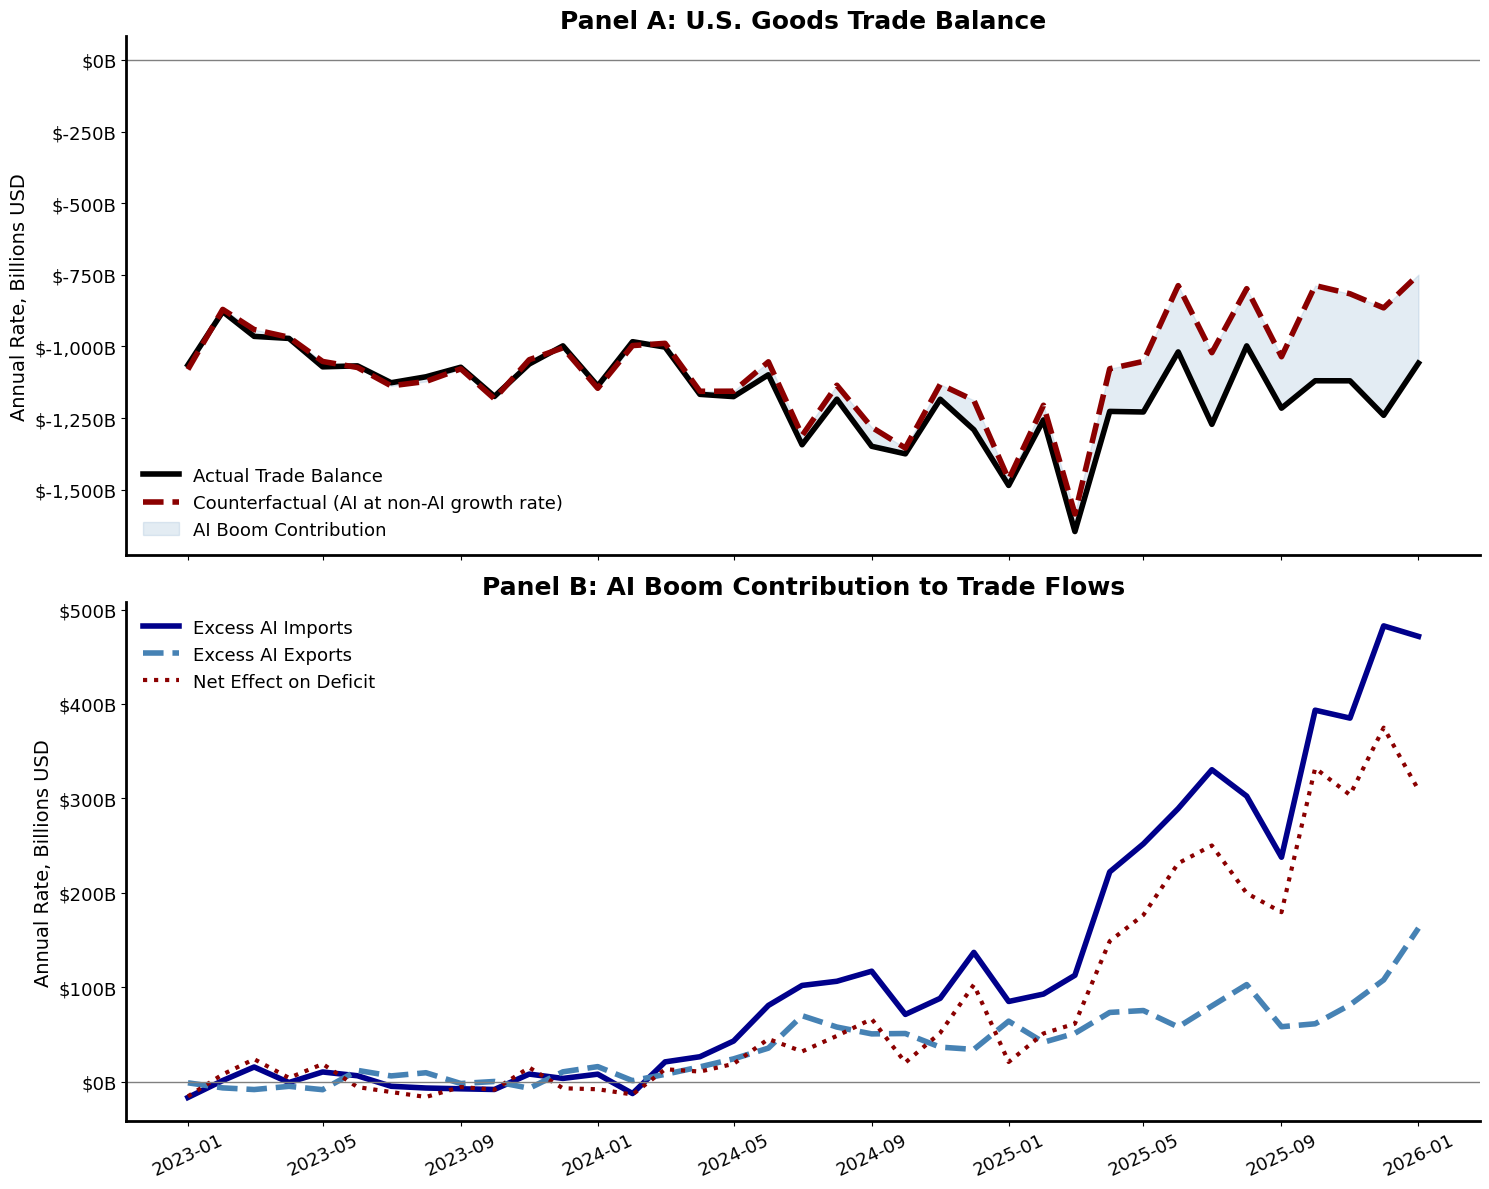

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# Panel A: trade balance
ax = axes[0]
ax.plot(common_idx, actual_balance * scale,
        color='black', linewidth=4, label='Actual Trade Balance')
ax.plot(common_idx, cf_balance * scale,
        color='darkred', linewidth=4, linestyle='--',
        label='Counterfactual (AI at non-AI growth rate)')
ax.fill_between(common_idx,
                actual_balance * scale, cf_balance * scale,
                alpha=0.15, color='steelblue', label='AI Boom Contribution')
ax.axhline(0, color='gray', linewidth=1)
ax.set_title('Panel A: U.S. Goods Trade Balance', fontsize=18, fontweight='bold')
ax.set_ylabel('Annual Rate, Billions USD', fontsize=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}B'))
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(2); ax.spines['bottom'].set_linewidth(2)
ax.tick_params(labelsize=13)
ax.legend(fontsize=13, frameon=False)

# Panel B: excess breakdown
ax2 = axes[1]
ax2.plot(common_idx, exc_imp * scale,
         color='darkblue', linewidth=4, label='Excess AI Imports')
ax2.plot(common_idx, exc_exp * scale,
         color='steelblue', linewidth=4, linestyle='--', label='Excess AI Exports')
ax2.plot(common_idx, (exc_imp - exc_exp) * scale,
         color='darkred', linewidth=3, linestyle=':', label='Net Effect on Deficit')
ax2.axhline(0, color='gray', linewidth=1)
ax2.set_title('Panel B: AI Boom Contribution to Trade Flows', fontsize=18, fontweight='bold')
ax2.set_ylabel('Annual Rate, Billions USD', fontsize=14)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}B'))
ax2.spines['right'].set_visible(False); ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_linewidth(2); ax2.spines['bottom'].set_linewidth(2)
ax2.tick_params(axis='x', labelsize=13, rotation=25)
ax2.tick_params(axis='y', labelsize=13)
ax2.legend(fontsize=13, frameon=False)

plt.tight_layout()
plt.savefig(figfile + 'counterfactual-balance.png', bbox_inches='tight')
plt.savefig(figfile + 'counterfactual-balance.pdf', bbox_inches='tight')
plt.show()


## Summary Statistics Table


In [24]:
years = [2023, 2024, 2025]
rows = []
for yr in years:
    yi = str(yr)
    try:
        a_imp  = actual_imp.loc[yi].sum() / 1e9
        a_exp  = actual_exp.loc[yi].sum() / 1e9
        a_bal  = actual_balance.loc[yi].sum() / 1e9
        cf_bal = cf_balance.loc[yi].sum() / 1e9
        exc_i  = exc_imp.loc[yi].sum() / 1e9
        exc_e  = exc_exp.loc[yi].sum() / 1e9
    except KeyError:
        continue
    rows.append({
        'Year': yr,
        'Actual Imports ($B)': round(a_imp, 0),
        'Actual Exports ($B)': round(a_exp, 0),
        'Actual Balance ($B)': round(a_bal, 0),
        'CF Balance ($B)':     round(cf_bal, 0),
        'Excess AI Imports ($B)': round(exc_i, 0),
        'Excess AI Exports ($B)': round(exc_e, 0),
        'Net AI Effect ($B)':  round(exc_i - exc_e, 0),
    })
summary = pd.DataFrame(rows).set_index('Year')
print(summary.to_string())


      Actual Imports ($B)  Actual Exports ($B)  Actual Balance ($B)  CF Balance ($B)  Excess AI Imports ($B)  Excess AI Exports ($B)  Net AI Effect ($B)
Year                                                                                                                                                    
2023               2598.0               1552.0              -1046.0          -1046.0                    -0.0                     0.0                -0.0
2024               2792.0               1601.0              -1191.0          -1158.0                    66.0                    33.0                32.0
2025               2884.0               1648.0              -1235.0          -1041.0                   265.0                    71.0               194.0


In [25]:
# Generate LaTeX table for counterfactual summary
import os
os.makedirs('paper/tables', exist_ok=True)

def fmt(val, is_net=False):
    """Format value with commas, or '---' if mechanically zero (base year)."""
    if val == 0:
        return "---"
    fmt_str = f"{val:+,.0f}" if is_net else f"{val:,.0f}"
    return fmt_str

table_file = "../paper/tables/counterfactual_summary.tex"
with open(table_file, 'w', encoding='utf-8') as f:
    f.write("\\begin{table}[htbp]\n")
    f.write("\\centering\n")
    f.write("\\caption{Accounting for AI's Impact on Trade (\\$B)}\n")
    f.write("\\label{tab:counterfactual_summary}\n")
    f.write("\\setlength{\\tabcolsep}{1.75mm}\n")
    f.write("\\renewcommand{\\arraystretch}{1.60}\n")
    f.write("{\\small\n")
    f.write("\\begin{tabular}{lccccc}\n")
    f.write("\\toprule\n")
    f.write("Year & Actual Imports & Actual Exports & Excess AI Imports & Excess AI Exports & Net Effect \\\\\n")
    # f.write(" & (\\$B) & (\\$B) & (\\$B) & (\\$B) & (\\$B) \\\\\n")
    f.write("\\midrule\n")
    for row in rows:
        yr  = row['Year']
        a_m = row['Actual Imports ($B)']
        a_x = row['Actual Exports ($B)']
        e_m = row['Excess AI Imports ($B)']
        e_x = row['Excess AI Exports ($B)']
        net = row['Net AI Effect ($B)']
        f.write(f"{yr} & {fmt(a_m)} & {fmt(a_x)} & {fmt(e_m)} & {fmt(e_x)} & {fmt(net, is_net=True)} \\\\\n")
    f.write("\\bottomrule\n")
    f.write("\\end{tabular}}\n")
    f.write("\\end{table}\n")

print(f"Generated: {table_file}")
print("=" * 70)
with open(table_file, 'r', encoding='utf-8') as f:
    print(f.read())
print("=" * 70)


Generated: ../paper/tables/counterfactual_summary.tex
\begin{table}[htbp]
\centering
\caption{Accounting for AI's Impact on Trade (\$B)}
\label{tab:counterfactual_summary}
\setlength{\tabcolsep}{1.75mm}
\renewcommand{\arraystretch}{1.60}
{\small
\begin{tabular}{lccccc}
\toprule
Year & Actual Imports & Actual Exports & Excess AI Imports & Excess AI Exports & Net Effect \\
\midrule
2023 & 2,598 & 1,552 & --- & --- & --- \\
2024 & 2,792 & 1,601 & 66 & 33 & +32 \\
2025 & 2,884 & 1,648 & 265 & 71 & +194 \\
\bottomrule
\end{tabular}}
\end{table}



In [26]:
# Write key numbers to LaTeX
yi = '2025'
excess_imp_ann = exc_imp.loc[yi].sum() / 1e9
excess_exp_ann = exc_exp.loc[yi].sum() / 1e9
net_eff        = excess_imp_ann - excess_exp_ann
actual_bal_ann = actual_balance.loc[yi].sum() / 1e9
cf_bal_ann     = cf_balance.loc[yi].sum() / 1e9
actual_deficit = abs(actual_bal_ann)
cf_deficit     = abs(cf_bal_ann)
deficit_reduction_pct = (net_eff / actual_deficit) * 100

with open(texfile, 'a') as f:
    f.write(f'\\def\\cfExcessAiImports{{{excess_imp_ann:.0f}}}\n')
    f.write(f'\\def\\cfExcessAiExports{{{excess_exp_ann:.0f}}}\n')
    f.write(f'\\def\\cfNetAiEffect{{{net_eff:.0f}}}\n')
    f.write(f'\\def\\cfActualBalance{{{actual_bal_ann:.0f}}}\n')
    f.write(f'\\def\\cfCounterfactualBalance{{{cf_bal_ann:.0f}}}\n')
    f.write(f'\\def\\cfActualDeficit{{{actual_deficit:,.0f}}} % Actual goods trade deficit 2025 ($B)\n')
    f.write(f'\\def\\cfCounterfactualDeficit{{{cf_deficit:,.0f}}} % Counterfactual goods trade deficit 2025 ($B)\n')
    f.write(f'\\def\\cfDeficitReductionPct{{{deficit_reduction_pct:.0f}}} % Deficit reduction from AI boom (%)\n')
print('LaTeX macros written.')


LaTeX macros written.
